# Proyecto 2

In [ ]:
%pip install -q \
    "gymnasium==1.3.0" \
    "ale-py==0.12.1" \
    "stable-baselines3[extra]>=2.7,<3.0" \
    "moviepy>=2.0" \
    "imageio-ffmpeg>=0.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 84.6 MB/s eta 0:00:00


In [ ]:
import torch

print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROYECTO = Path("/content/drive/MyDrive/CC3092/pry2")

for carpeta in ["models", "checkpoints", "logs", "results", "videos"]:
    (PROYECTO / carpeta).mkdir(parents=True, exist_ok=True)

print("Carpeta del proyecto:", PROYECTO)

for ruta in sorted(PROYECTO.iterdir()):
    print("-", ruta.name)

Carpeta del proyecto: /content/drive/MyDrive/CC3092/pry2
- checkpoints
- logs
- models
- results
- videos


In [ ]:
import gymnasium as gym
import ale_py
import stable_baselines3 as sb3

gym.register_envs(ale_py)

env = gym.make("ALE/SpaceInvaders-v5")
observacion, info = env.reset(seed=42)

print("Gymnasium:", gym.__version__)
print("ALE:", ale_py.__version__)
print("Stable-Baselines3:", sb3.__version__)
print("Observación:", observacion.shape, observacion.dtype)
print("Espacio de acciones:", env.action_space)
print("Acciones:", env.unwrapped.get_action_meanings())
print("Vidas:", info.get("lives"))

env.close()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Gymnasium: 1.3.0
ALE: 0.12.1
Stable-Baselines3: 2.9.0
Observación: (210, 160, 3) uint8
Espacio de acciones: Discrete(6)
Acciones: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Vidas: 3


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import numpy as np
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

base_env = gym.make(
    "ALE/SpaceInvaders-v5",
    frameskip=1,
    full_action_space=False,
)

env = AtariPreprocessing(
    base_env,
    noop_max=30,
    frame_skip=4,
    screen_size=84,
    grayscale_obs=True,
    scale_obs=False,
    terminal_on_life_loss=False,
)

env = FrameStackObservation(env, stack_size=4)

observacion, info = env.reset(seed=42)
observacion = np.asarray(observacion)

print("Forma procesada:", observacion.shape)
print("Tipo:", observacion.dtype)
print("Valores mínimo/máximo:", observacion.min(), observacion.max())
print("Acciones:", env.action_space)

accion = env.action_space.sample()
_, recompensa, terminated, truncated, _ = env.step(accion)

print("Primer paso correcto")
print("Recompensa:", recompensa)
print("Terminated:", terminated)
print("Truncated:", truncated)

env.close()

Forma procesada: (4, 84, 84)
Tipo: uint8
Valores mínimo/máximo: 0 133
Acciones: Discrete(6)
Primer paso correcto
Recompensa: 0.0
Terminated: False
Truncated: False


## Configuración oficial del entorno

- **Entorno:** `ALE/SpaceInvaders-v5`.
- **Observación original:** imagen RGB de `210 × 160 × 3`.
- **Espacio de acciones:** subconjunto mínimo de 6 acciones (`full_action_space=False`).
- **Frame skip del entorno base:** `1`, para evitar duplicarlo con `AtariPreprocessing`.
- **Frame skip efectivo:** `4`, aplicado por `AtariPreprocessing`.
- **Preprocesamiento:** escala de grises y redimensionamiento a `84 × 84`.
- **Frame stacking:** apilamiento de 4 observaciones para representar movimiento.
- **Tipo de observación:** `uint8`; la política CNN realizará la normalización.
- **Pérdida de una vida:** no finaliza el episodio (`terminal_on_life_loss=False`).
- **Final del episodio:** ocurre al perder todas las vidas o alcanzar el límite del entorno.
- **Semilla inicial de desarrollo:** `42`.

In [ ]:
spec = gym.spec("ALE/SpaceInvaders-v5")

print("Parámetros predeterminados de ALE/SpaceInvaders-v5:")
for nombre, valor in spec.kwargs.items():
    print(f"- {nombre}: {valor}")

Parámetros predeterminados de ALE/SpaceInvaders-v5:
- game: space_invaders
- repeat_action_probability: 0.25
- full_action_space: False
- frameskip: 4
- max_num_frames_per_episode: 108000


In [ ]:
CONFIG_ENTORNO = {
    "env_id": "ALE/SpaceInvaders-v5",
    "seed": 42,
    "base_frameskip": 1,
    "repeat_action_probability": 0.25,
    "full_action_space": False,
    "noop_max": 30,
    "frame_skip": 4,
    "screen_size": 84,
    "grayscale_obs": True,
    "scale_obs": False,
    "terminal_on_life_loss": False,
    "stack_size": 4,
}

for nombre, valor in CONFIG_ENTORNO.items():
    print(f"{nombre}: {valor}")

env_id: ALE/SpaceInvaders-v5
seed: 42
base_frameskip: 1
repeat_action_probability: 0.25
full_action_space: False
noop_max: 30
frame_skip: 4
screen_size: 84
grayscale_obs: True
scale_obs: False
terminal_on_life_loss: False
stack_size: 4


In [ ]:
def crear_entorno_procesado(render_mode=None, seed=None):
    """Crea Space Invaders con la configuración oficial del proyecto."""

    env = gym.make(
        CONFIG_ENTORNO["env_id"],
        render_mode=render_mode,
        frameskip=CONFIG_ENTORNO["base_frameskip"],
        repeat_action_probability=CONFIG_ENTORNO["repeat_action_probability"],
        full_action_space=CONFIG_ENTORNO["full_action_space"],
    )

    env = AtariPreprocessing(
        env,
        noop_max=CONFIG_ENTORNO["noop_max"],
        frame_skip=CONFIG_ENTORNO["frame_skip"],
        screen_size=CONFIG_ENTORNO["screen_size"],
        grayscale_obs=CONFIG_ENTORNO["grayscale_obs"],
        scale_obs=CONFIG_ENTORNO["scale_obs"],
        terminal_on_life_loss=CONFIG_ENTORNO["terminal_on_life_loss"],
    )

    env = FrameStackObservation(
        env,
        stack_size=CONFIG_ENTORNO["stack_size"],
    )

    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)

    return env


print("Función crear_entorno_procesado creada correctamente")

Función crear_entorno_procesado creada correctamente


In [ ]:
env_prueba = crear_entorno_procesado(seed=CONFIG_ENTORNO["seed"])
observacion, info = env_prueba.reset(seed=CONFIG_ENTORNO["seed"])
observacion = np.asarray(observacion)

assert observacion.shape == (4, 84, 84)
assert observacion.dtype == np.uint8
assert env_prueba.action_space.n == 6

recompensa_total = 0.0

for _ in range(100):
    accion = env_prueba.action_space.sample()
    observacion, recompensa, terminated, truncated, info = env_prueba.step(accion)
    recompensa_total += float(recompensa)

    if terminated or truncated:
        break

env_prueba.close()

print("Validación superada")
print("Forma:", np.asarray(observacion).shape)
print("Acciones:", 6)
print("Pasos ejecutados:", _ + 1)
print("Recompensa acumulada:", recompensa_total)

Validación superada
Forma: (4, 84, 84)
Acciones: 6
Pasos ejecutados: 100
Recompensa acumulada: 0.0


In [ ]:
import json

registro_configuracion = {
    "entorno": CONFIG_ENTORNO,
    "versiones": {
        "gymnasium": gym.__version__,
        "ale_py": ale_py.__version__,
        "stable_baselines3": sb3.__version__,
        "torch": torch.__version__,
    },
}

ruta_configuracion = PROYECTO / "results" / "configuracion_entorno.json"

ruta_configuracion.write_text(
    json.dumps(registro_configuracion, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Configuración guardada en:")
print(ruta_configuracion)
print("Existe:", ruta_configuracion.exists())

Configuración guardada en:
/content/drive/MyDrive/CC3092/pry2/results/configuracion_entorno.json
Existe: True


In [ ]:
def agente_aleatorio(observacion, env):
    """Selecciona cualquiera de las seis acciones al azar."""
    return env.action_space.sample()


def agente_solo_disparar(observacion, env):
    """Permanece inmóvil y utiliza siempre la acción FIRE."""
    acciones = env.unwrapped.get_action_meanings()
    return acciones.index("FIRE")


env_prueba = crear_entorno_procesado(seed=42)
observacion, _ = env_prueba.reset(seed=42)

accion_aleatoria = agente_aleatorio(observacion, env_prueba)
accion_disparo = agente_solo_disparar(observacion, env_prueba)

print("Acción aleatoria:", accion_aleatoria)
print("Acción solo disparar:", accion_disparo)
print("Significado:", env_prueba.unwrapped.get_action_meanings()[accion_disparo])

env_prueba.close()

Acción aleatoria: 0
Acción solo disparar: 1
Significado: FIRE


In [ ]:
def ejecutar_episodio(
    env,
    funcion_agente,
    seed=None,
    max_steps=30000,
):
    """Ejecuta un episodio y devuelve sus métricas."""

    if seed is not None:
        env.action_space.seed(seed)

    observacion, _ = env.reset(seed=seed)

    recompensa_total = 0.0
    pasos = 0
    terminated = False
    truncated = False

    while not (terminated or truncated) and pasos < max_steps:
        accion = funcion_agente(observacion, env)

        observacion, recompensa, terminated, truncated, _ = env.step(accion)

        recompensa_total += float(recompensa)
        pasos += 1

    return {
        "seed": seed,
        "pasos": pasos,
        "recompensa_total": recompensa_total,
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "limite_alcanzado": pasos >= max_steps,
    }


env_prueba = crear_entorno_procesado()
resultado_prueba = ejecutar_episodio(
    env_prueba,
    agente_aleatorio,
    seed=42,
    max_steps=200,
)
env_prueba.close()

print(resultado_prueba)

{'seed': 42, 'pasos': 200, 'recompensa_total': 45.0, 'terminated': False, 'truncated': False, 'limite_alcanzado': True}


In [ ]:
import pandas as pd


def evaluar_agente(
    nombre_agente,
    funcion_agente,
    semillas,
    max_steps=30000,
):
    """Evalúa un agente en varias semillas independientes."""

    registros = []

    for numero, semilla in enumerate(semillas, start=1):
        env = crear_entorno_procesado()

        try:
            resultado = ejecutar_episodio(
                env,
                funcion_agente,
                seed=semilla,
                max_steps=max_steps,
            )
        finally:
            env.close()

        resultado["episodio"] = numero
        resultado["agente"] = nombre_agente
        registros.append(resultado)

        print(
            f"Episodio {numero}: "
            f"recompensa={resultado['recompensa_total']}, "
            f"pasos={resultado['pasos']}"
        )

    resultados = pd.DataFrame(registros)

    resumen = {
        "agente": nombre_agente,
        "episodios": len(resultados),
        "recompensa_promedio": float(resultados["recompensa_total"].mean()),
        "recompensa_maxima": float(resultados["recompensa_total"].max()),
        "recompensa_minima": float(resultados["recompensa_total"].min()),
        "desviacion_estandar": float(resultados["recompensa_total"].std(ddof=0)),
    }

    return resultados, resumen


prueba_resultados, prueba_resumen = evaluar_agente(
    nombre_agente="aleatorio_prueba",
    funcion_agente=agente_aleatorio,
    semillas=[100],
    max_steps=300,
)

print("\nResumen:")
print(prueba_resumen)

Episodio 1: recompensa=105.0, pasos=300

Resumen:
{'agente': 'aleatorio_prueba', 'episodios': 1, 'recompensa_promedio': 105.0, 'recompensa_maxima': 105.0, 'recompensa_minima': 105.0, 'desviacion_estandar': 0.0}


In [ ]:
SEMILLAS_EVALUACION = [100, 101, 102, 103, 104]

resultados_aleatorio, resumen_aleatorio = evaluar_agente(
    nombre_agente="aleatorio",
    funcion_agente=agente_aleatorio,
    semillas=SEMILLAS_EVALUACION,
    max_steps=30000,
)

print("\nResultados por episodio:")
display(
    resultados_aleatorio[
        ["episodio", "seed", "pasos", "recompensa_total"]
    ]
)

print("\nResumen del baseline aleatorio:")
for nombre, valor in resumen_aleatorio.items():
    print(f"{nombre}: {valor}")

Episodio 1: recompensa=105.0, pasos=325
Episodio 2: recompensa=135.0, pasos=569
Episodio 3: recompensa=55.0, pasos=480
Episodio 4: recompensa=175.0, pasos=651
Episodio 5: recompensa=215.0, pasos=625

Resultados por episodio:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episodio,seed,pasos,recompensa_total
0,1,100,325,105.0
1,2,101,569,135.0
2,3,102,480,55.0
3,4,103,651,175.0
4,5,104,625,215.0



Resumen del baseline aleatorio:
agente: aleatorio
episodios: 5
recompensa_promedio: 137.0
recompensa_maxima: 215.0
recompensa_minima: 55.0
desviacion_estandar: 55.281099844341014


In [ ]:
resultados_disparar, resumen_disparar = evaluar_agente(
    nombre_agente="solo_disparar",
    funcion_agente=agente_solo_disparar,
    semillas=SEMILLAS_EVALUACION,
    max_steps=30000,
)

print("\nResultados por episodio:")
display(
    resultados_disparar[
        ["episodio", "seed", "pasos", "recompensa_total"]
    ]
)

print("\nResumen del baseline solo disparar:")
for nombre, valor in resumen_disparar.items():
    print(f"{nombre}: {valor}")

Episodio 1: recompensa=285.0, pasos=719
Episodio 2: recompensa=285.0, pasos=724
Episodio 3: recompensa=285.0, pasos=725
Episodio 4: recompensa=285.0, pasos=721
Episodio 5: recompensa=285.0, pasos=724

Resultados por episodio:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episodio,seed,pasos,recompensa_total
0,1,100,719,285.0
1,2,101,724,285.0
2,3,102,725,285.0
3,4,103,721,285.0
4,5,104,724,285.0



Resumen del baseline solo disparar:
agente: solo_disparar
episodios: 5
recompensa_promedio: 285.0
recompensa_maxima: 285.0
recompensa_minima: 285.0
desviacion_estandar: 0.0


In [ ]:
resultados_baselines = pd.concat(
    [resultados_aleatorio, resultados_disparar],
    ignore_index=True,
)

resumen_baselines = {
    "semillas_evaluacion": SEMILLAS_EVALUACION,
    "aleatorio": resumen_aleatorio,
    "solo_disparar": resumen_disparar,
}

ruta_episodios = PROYECTO / "results" / "baselines_episodios.csv"
ruta_resumen = PROYECTO / "results" / "baselines_resumen.json"

resultados_baselines.to_csv(ruta_episodios, index=False)

ruta_resumen.write_text(
    json.dumps(resumen_baselines, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Archivos guardados:")
print("-", ruta_episodios)
print("-", ruta_resumen)
print("CSV existe:", ruta_episodios.exists())
print("JSON existe:", ruta_resumen.exists())

Archivos guardados:
- /content/drive/MyDrive/CC3092/pry2/results/baselines_episodios.csv
- /content/drive/MyDrive/CC3092/pry2/results/baselines_resumen.json
CSV existe: True
JSON existe: True


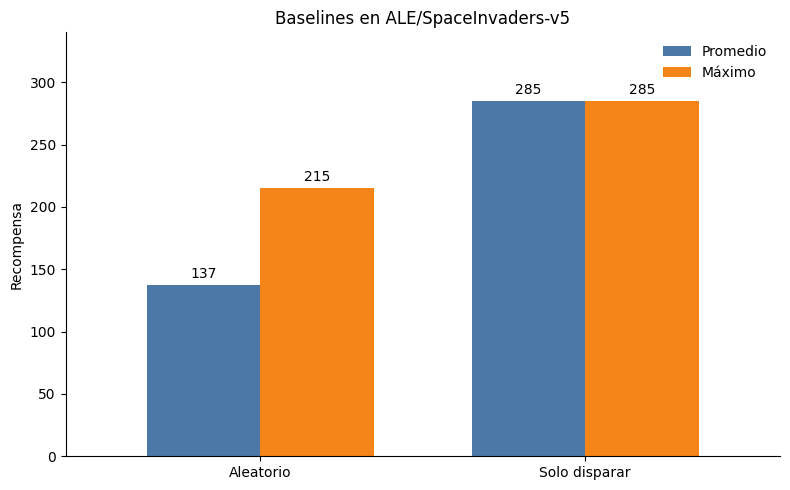

Gráfica guardada en:
/content/drive/MyDrive/CC3092/pry2/results/baselines_comparacion.png
Existe: True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt

comparacion_baselines = pd.DataFrame([
    {
        "Agente": "Aleatorio",
        "Promedio": resumen_aleatorio["recompensa_promedio"],
        "Máximo": resumen_aleatorio["recompensa_maxima"],
    },
    {
        "Agente": "Solo disparar",
        "Promedio": resumen_disparar["recompensa_promedio"],
        "Máximo": resumen_disparar["recompensa_maxima"],
    },
])

fig, ax = plt.subplots(figsize=(8, 5))

comparacion_baselines.set_index("Agente").plot(
    kind="bar",
    ax=ax,
    color=["#4C78A8", "#F58518"],
    width=0.7,
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f", padding=3)

ax.set_title("Baselines en ALE/SpaceInvaders-v5")
ax.set_xlabel("")
ax.set_ylabel("Recompensa")
ax.set_ylim(0, 340)
ax.tick_params(axis="x", rotation=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()

ruta_figura = PROYECTO / "results" / "baselines_comparacion.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")

plt.show()

print("Gráfica guardada en:")
print(ruta_figura)
print("Existe:", ruta_figura.exists())

In [ ]:
CONFIG_DQN = {
    "id_experimento": "DQN_01",
    "policy": "CnnPolicy",
    "total_timesteps": 500_000,
    "learning_rate": 1e-4,
    "buffer_size": 100_000,
    "learning_starts": 20_000,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 10_000,
    "exploration_fraction": 0.20,
    "exploration_initial_eps": 1.0,
    "exploration_final_eps": 0.05,
    "max_grad_norm": 10.0,
    "optimize_memory_usage": True,
    "seed": 42,
}

for nombre, valor in CONFIG_DQN.items():
    print(f"{nombre}: {valor}")

id_experimento: DQN_01
policy: CnnPolicy
total_timesteps: 500000
learning_rate: 0.0001
buffer_size: 100000
learning_starts: 20000
batch_size: 32
gamma: 0.99
train_freq: 4
gradient_steps: 1
target_update_interval: 10000
exploration_fraction: 0.2
exploration_initial_eps: 1.0
exploration_final_eps: 0.05
max_grad_norm: 10.0
optimize_memory_usage: True
seed: 42


In [ ]:
from stable_baselines3.common.monitor import Monitor


class ClipRewardEnv(gym.RewardWrapper):
    """Convierte cada recompensa a -1, 0 o 1 durante el entrenamiento."""

    def reward(self, reward):
        return float(np.sign(reward))


def crear_entorno_entrenamiento(seed, nombre_log):
    env = crear_entorno_procesado(seed=seed)

    # Monitor se coloca antes del clipping para registrar el puntaje real.
    env = Monitor(
        env,
        filename=str(PROYECTO / "logs" / nombre_log),
    )

    # El agente recibe la recompensa recortada.
    env = ClipRewardEnv(env)

    return env


env_entrenamiento_prueba = crear_entorno_entrenamiento(
    seed=CONFIG_DQN["seed"],
    nombre_log="prueba_monitor",
)

observacion, _ = env_entrenamiento_prueba.reset(
    seed=CONFIG_DQN["seed"]
)

print("Observación:", np.asarray(observacion).shape)
print("Acciones:", env_entrenamiento_prueba.action_space)
print("Wrapper exterior:", type(env_entrenamiento_prueba).__name__)
print("Wrapper de métricas:", type(env_entrenamiento_prueba.env).__name__)

env_entrenamiento_prueba.close()

Observación: (4, 84, 84)
Acciones: Discrete(6)
Wrapper exterior: ClipRewardEnv
Wrapper de métricas: Monitor


In [ ]:
from stable_baselines3 import DQN

env_entrenamiento = crear_entorno_entrenamiento(
    seed=CONFIG_DQN["seed"],
    nombre_log=f"{CONFIG_DQN['id_experimento']}_train",
)

modelo_dqn = DQN(
    policy=CONFIG_DQN["policy"],
    env=env_entrenamiento,
    learning_rate=CONFIG_DQN["learning_rate"],
    buffer_size=CONFIG_DQN["buffer_size"],
    learning_starts=CONFIG_DQN["learning_starts"],
    batch_size=CONFIG_DQN["batch_size"],
    gamma=CONFIG_DQN["gamma"],
    train_freq=CONFIG_DQN["train_freq"],
    gradient_steps=CONFIG_DQN["gradient_steps"],
    target_update_interval=CONFIG_DQN["target_update_interval"],
    exploration_fraction=CONFIG_DQN["exploration_fraction"],
    exploration_initial_eps=CONFIG_DQN["exploration_initial_eps"],
    exploration_final_eps=CONFIG_DQN["exploration_final_eps"],
    max_grad_norm=CONFIG_DQN["max_grad_norm"],
    optimize_memory_usage=CONFIG_DQN["optimize_memory_usage"],
    replay_buffer_kwargs={
        "handle_timeout_termination": False,
    },
    tensorboard_log=str(PROYECTO / "logs" / "tensorboard"),
    seed=CONFIG_DQN["seed"],
    device="cuda",
    verbose=1,
)

print("\nModelo creado")
print("Dispositivo:", modelo_dqn.device)
print("Política:", type(modelo_dqn.policy).__name__)
print("Extractor CNN:", type(modelo_dqn.policy.q_net.features_extractor).__name__)

Using cuda device
Wrapping the env in a DummyVecEnv.

Modelo creado
Dispositivo: cuda
Política: CnnPolicy
Extractor CNN: NatureCNN


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback,
    EvalCallback,
)

carpeta_checkpoints = (
    PROYECTO / "checkpoints" / CONFIG_DQN["id_experimento"]
)
carpeta_mejor_modelo = (
    PROYECTO / "models" / CONFIG_DQN["id_experimento"]
)
carpeta_evaluacion = (
    PROYECTO / "results" / CONFIG_DQN["id_experimento"]
)

for carpeta in [
    carpeta_checkpoints,
    carpeta_mejor_modelo,
    carpeta_evaluacion,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

env_evaluacion_callback = crear_entorno_procesado(seed=100)
env_evaluacion_callback = Monitor(env_evaluacion_callback)

callback_checkpoint = CheckpointCallback(
    save_freq=10_000,
    save_path=str(carpeta_checkpoints),
    name_prefix="dqn_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False,
)

callback_evaluacion = EvalCallback(
    env_evaluacion_callback,
    best_model_save_path=str(carpeta_mejor_modelo),
    log_path=str(carpeta_evaluacion),
    eval_freq=10_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
)

callbacks_dqn = CallbackList([
    callback_checkpoint,
    callback_evaluacion,
])

print("Callbacks configurados")
print("Checkpoints:", carpeta_checkpoints)
print("Mejor modelo:", carpeta_mejor_modelo)
print("Evaluaciones:", carpeta_evaluacion)

Callbacks configurados
Checkpoints: /content/drive/MyDrive/CC3092/pry2/checkpoints/DQN_01
Mejor modelo: /content/drive/MyDrive/CC3092/pry2/models/DQN_01
Evaluaciones: /content/drive/MyDrive/CC3092/pry2/results/DQN_01


In [ ]:
configuracion_experimento = {
    "id_experimento": CONFIG_DQN["id_experimento"],
    "algoritmo": "DQN",
    "arquitectura": "NatureCNN",
    "reward_clipping_entrenamiento": True,
    "entorno": CONFIG_ENTORNO,
    "hiperparametros": CONFIG_DQN,
    "evaluacion": {
        "episodios_por_evaluacion": 5,
        "frecuencia": 10_000,
        "politica_determinista": True,
        "recompensa_sin_clipping": True,
    },
    "versiones": {
        "gymnasium": gym.__version__,
        "ale_py": ale_py.__version__,
        "stable_baselines3": sb3.__version__,
        "torch": torch.__version__,
    },
}

ruta_experimento = (
    carpeta_evaluacion / "configuracion_experimento.json"
)

ruta_experimento.write_text(
    json.dumps(
        configuracion_experimento,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Configuración guardada:")
print(ruta_experimento)
print("Existe:", ruta_experimento.exists())

Configuración guardada:
/content/drive/MyDrive/CC3092/pry2/results/DQN_01/configuracion_experimento.json
Existe: True


In [ ]:
PASOS_PRUEBA = 25_000

modelo_dqn.learn(
    total_timesteps=PASOS_PRUEBA,
    callback=callbacks_dqn,
    log_interval=10,
    tb_log_name="DQN_01_smoke",
    reset_num_timesteps=True,
    progress_bar=True,
)

ruta_modelo_prueba = (
    carpeta_mejor_modelo / "modelo_smoke_test"
)

modelo_dqn.save(ruta_modelo_prueba)

print("\nPrueba de entrenamiento terminada")
print("Pasos:", modelo_dqn.num_timesteps)
print("Modelo guardado en:", ruta_modelo_prueba)

Logging to /content/drive/MyDrive/CC3092/pry2/logs/tensorboard/DQN_01_smoke_1


Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 550      |
|    ep_rew_mean      | 158      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 10       |
|    fps              | 631      |
|    time_elapsed     | 8        |
|    total_timesteps  | 5505     |
----------------------------------


Eval num_timesteps=10000, episode_reward=0.00 +/- 0.00

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 543      |
|    ep_rew_mean      | 161      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 20       |
|    fps              | 433      |
|    time_elapsed     | 25       |
|    total_timesteps  | 10860    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 521      |
|    ep_rew_mean      | 152      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 30       |
|    fps              | 483      |
|    time_elapsed     | 32       |
|    total_timesteps  | 15631    |
----------------------------------


Eval num_timesteps=20000, episode_reward=0.00 +/- 0.00

Episode length: 688.60 +/- 1.02

----------------------------------
| eval/               |          |
|    mean_ep_length   | 689      |
|    mean_reward      | 0        |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 20000    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 502      |
|    ep_rew_mean      | 151      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 40       |
|    fps              | 423      |
|    time_elapsed     | 47       |
|    total_timesteps  | 20098    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0152   |
|    n_updates        | 24       |
----------------------------------



Prueba de entrenamiento terminada
Pasos: 25000
Modelo guardado en: /content/drive/MyDrive/CC3092/pry2/models/DQN_01/modelo_smoke_test


In [ ]:
carpetas_verificar = [
    carpeta_checkpoints,
    carpeta_mejor_modelo,
    carpeta_evaluacion,
]

for carpeta in carpetas_verificar:
    print(f"\n{carpeta}:")

    for archivo in sorted(carpeta.glob("*")):
        if archivo.is_file():
            tamaño_mb = archivo.stat().st_size / (1024 ** 2)
            print(f"- {archivo.name}: {tamaño_mb:.2f} MB")


/content/drive/MyDrive/CC3092/pry2/checkpoints/DQN_01:
- dqn_space_invaders_10000_steps.zip: 13.11 MB
- dqn_space_invaders_20000_steps.zip: 13.11 MB

/content/drive/MyDrive/CC3092/pry2/models/DQN_01:
- best_model.zip: 13.11 MB
- modelo_smoke_test.zip: 25.99 MB

/content/drive/MyDrive/CC3092/pry2/results/DQN_01:
- configuracion_experimento.json: 0.00 MB
- evaluations.npz: 0.00 MB


In [ ]:
import gc

env_entrenamiento.close()
env_evaluacion_callback.close()

del modelo_dqn
del callbacks_dqn
del callback_checkpoint
del callback_evaluacion
del env_entrenamiento
del env_evaluacion_callback

gc.collect()
torch.cuda.empty_cache()

ID_ENTRENAMIENTO = "DQN_01_full"

carpeta_checkpoints_full = (
    PROYECTO / "checkpoints" / ID_ENTRENAMIENTO
)
carpeta_modelo_full = (
    PROYECTO / "models" / ID_ENTRENAMIENTO
)
carpeta_resultados_full = (
    PROYECTO / "results" / ID_ENTRENAMIENTO
)

for carpeta in [
    carpeta_checkpoints_full,
    carpeta_modelo_full,
    carpeta_resultados_full,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Memoria del modelo de prueba liberada")
print("Experimento:", ID_ENTRENAMIENTO)
print("Checkpoints:", carpeta_checkpoints_full)
print("Modelos:", carpeta_modelo_full)
print("Resultados:", carpeta_resultados_full)

Memoria del modelo de prueba liberada
Experimento: DQN_01_full
Checkpoints: /content/drive/MyDrive/CC3092/pry2/checkpoints/DQN_01_full
Modelos: /content/drive/MyDrive/CC3092/pry2/models/DQN_01_full
Resultados: /content/drive/MyDrive/CC3092/pry2/results/DQN_01_full


In [ ]:
CONFIG_DQN_FULL = {
    **CONFIG_DQN,
    "id_experimento": ID_ENTRENAMIENTO,
    "total_timesteps": 500_000,
}

env_entrenamiento_full = crear_entorno_entrenamiento(
    seed=CONFIG_DQN_FULL["seed"],
    nombre_log=f"{ID_ENTRENAMIENTO}_train",
)

modelo_dqn_full = DQN(
    policy=CONFIG_DQN_FULL["policy"],
    env=env_entrenamiento_full,
    learning_rate=CONFIG_DQN_FULL["learning_rate"],
    buffer_size=CONFIG_DQN_FULL["buffer_size"],
    learning_starts=CONFIG_DQN_FULL["learning_starts"],
    batch_size=CONFIG_DQN_FULL["batch_size"],
    gamma=CONFIG_DQN_FULL["gamma"],
    train_freq=CONFIG_DQN_FULL["train_freq"],
    gradient_steps=CONFIG_DQN_FULL["gradient_steps"],
    target_update_interval=CONFIG_DQN_FULL["target_update_interval"],
    exploration_fraction=CONFIG_DQN_FULL["exploration_fraction"],
    exploration_initial_eps=CONFIG_DQN_FULL["exploration_initial_eps"],
    exploration_final_eps=CONFIG_DQN_FULL["exploration_final_eps"],
    max_grad_norm=CONFIG_DQN_FULL["max_grad_norm"],
    optimize_memory_usage=CONFIG_DQN_FULL["optimize_memory_usage"],
    replay_buffer_kwargs={
        "handle_timeout_termination": False,
    },
    tensorboard_log=str(PROYECTO / "logs" / "tensorboard"),
    seed=CONFIG_DQN_FULL["seed"],
    device="cuda",
    verbose=1,
)

env_evaluacion_full = crear_entorno_procesado(seed=100)
env_evaluacion_full = Monitor(env_evaluacion_full)

checkpoint_full = CheckpointCallback(
    save_freq=50_000,
    save_path=str(carpeta_checkpoints_full),
    name_prefix="dqn_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False,
)

evaluacion_full = EvalCallback(
    env_evaluacion_full,
    best_model_save_path=str(carpeta_modelo_full),
    log_path=str(carpeta_resultados_full),
    eval_freq=50_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
)

callbacks_full = CallbackList([
    checkpoint_full,
    evaluacion_full,
])

print("\nModelo limpio preparado")
print("Dispositivo:", modelo_dqn_full.device)
print("Pasos planificados:", CONFIG_DQN_FULL["total_timesteps"])
print("Evaluación cada:", 50_000)
print("Checkpoint cada:", 50_000)

Using cuda device
Wrapping the env in a DummyVecEnv.

Modelo limpio preparado
Dispositivo: cuda
Pasos planificados: 500000
Evaluación cada: 50000
Checkpoint cada: 50000


In [ ]:
import time
from datetime import datetime, timezone

inicio_entrenamiento = time.time()
fecha_inicio = datetime.now(timezone.utc).isoformat()

modelo_dqn_full.learn(
    total_timesteps=CONFIG_DQN_FULL["total_timesteps"],
    callback=callbacks_full,
    log_interval=20,
    tb_log_name=ID_ENTRENAMIENTO,
    reset_num_timesteps=True,
    progress_bar=True,
)

duracion_segundos = time.time() - inicio_entrenamiento

ruta_modelo_final_dqn01 = (
    carpeta_modelo_full / "modelo_final"
)

modelo_dqn_full.save(ruta_modelo_final_dqn01)

registro_entrenamiento = {
    "id_experimento": ID_ENTRENAMIENTO,
    "estado": "completado",
    "fecha_inicio_utc": fecha_inicio,
    "duracion_segundos": duracion_segundos,
    "duracion_minutos": duracion_segundos / 60,
    "timesteps": modelo_dqn_full.num_timesteps,
    "modelo_final": str(ruta_modelo_final_dqn01) + ".zip",
    "configuracion": CONFIG_DQN_FULL,
}

ruta_registro = (
    carpeta_resultados_full / "registro_entrenamiento.json"
)

ruta_registro.write_text(
    json.dumps(registro_entrenamiento, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("\nEntrenamiento finalizado")
print("Pasos:", modelo_dqn_full.num_timesteps)
print("Duración en minutos:", round(duracion_segundos / 60, 2))
print("Modelo:", str(ruta_modelo_final_dqn01) + ".zip")
print("Registro:", ruta_registro)

Logging to /content/drive/MyDrive/CC3092/pry2/logs/tensorboard/DQN_01_full_1


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 543      |
|    ep_rew_mean      | 161      |
|    exploration_rate | 0.897    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 722      |
|    time_elapsed     | 15       |
|    total_timesteps  | 10860    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 503      |
|    ep_rew_mean      | 154      |
|    exploration_rate | 0.809    |
| time/               |          |
|    episodes         | 40       |
|    fps              | 720      |
|    time_elapsed     | 27       |
|    total_timesteps  | 20135    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0306   |
|    n_updates        | 33       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

Eval num_timesteps=50000, episode_reward=119.00 +/- 51.13

Episode length: 520.60 +/- 57.10

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 635      |
|    mean_reward      | 424      |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 450000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0157   |
|    n_updates        | 107499   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 602      |
|    ep_rew_mean      | 349      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 860      |
|    fps              | 255      |
|    time_elapsed     | 1778     |
|    total_timesteps  | 454435   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0101   |
|    n_updates        | 108608   |
----------------------------------
--------------------

Eval num_timesteps=500000, episode_reward=436.00 +/- 218.41

Episode length: 637.20 +/- 176.67

----------------------------------
| eval/               |          |
|    mean_ep_length   | 637      |
|    mean_reward      | 436      |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 500000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0125   |
|    n_updates        | 119999   |
----------------------------------



Entrenamiento finalizado
Pasos: 500000
Duración en minutos: 32.79
Modelo: /content/drive/MyDrive/CC3092/pry2/models/DQN_01_full/modelo_final.zip
Registro: /content/drive/MyDrive/CC3092/pry2/results/DQN_01_full/registro_entrenamiento.json


In [ ]:
ruta_mejor_modelo = carpeta_modelo_full / "best_model.zip"
ruta_modelo_final = carpeta_modelo_full / "modelo_final.zip"

modelo_mejor_dqn01 = DQN.load(
    ruta_mejor_modelo,
    device="cuda",
)

modelo_final_dqn01 = DQN.load(
    ruta_modelo_final,
    device="cuda",
)

print("Mejor modelo:")
print("- existe:", ruta_mejor_modelo.exists())
print("- pasos:", modelo_mejor_dqn01.num_timesteps)

print("\nModelo final:")
print("- existe:", ruta_modelo_final.exists())
print("- pasos:", modelo_final_dqn01.num_timesteps)

NameError: name 'carpeta_modelo_full' is not defined

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import gymnasium as gym
import ale_py

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
from stable_baselines3 import DQN

gym.register_envs(ale_py)

PROYECTO = Path("/content/drive/MyDrive/CC3092/pry2")
ID_ENTRENAMIENTO = "DQN_01_full"

carpeta_modelo_full = (
    PROYECTO / "models" / ID_ENTRENAMIENTO
)

ruta_mejor_modelo = carpeta_modelo_full / "best_model.zip"
ruta_modelo_final = carpeta_modelo_full / "modelo_final.zip"

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

modelo_mejor_dqn01 = DQN.load(
    ruta_mejor_modelo,
    device=dispositivo,
)

modelo_final_dqn01 = DQN.load(
    ruta_modelo_final,
    device=dispositivo,
)

print("Dispositivo:", dispositivo)

print("\nMejor modelo:")
print("- existe:", ruta_mejor_modelo.exists())
print("- pasos:", modelo_mejor_dqn01.num_timesteps)

print("\nModelo final:")
print("- existe:", ruta_modelo_final.exists())
print("- pasos:", modelo_final_dqn01.num_timesteps)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dispositivo: cuda

Mejor modelo:
- existe: True
- pasos: 400000

Modelo final:
- existe: True
- pasos: 500000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
CONFIG_ENTORNO = {
    "env_id": "ALE/SpaceInvaders-v5",
    "base_frameskip": 1,
    "repeat_action_probability": 0.25,
    "full_action_space": False,
    "noop_max": 30,
    "frame_skip": 4,
    "screen_size": 84,
    "grayscale_obs": True,
    "scale_obs": False,
    "terminal_on_life_loss": False,
    "stack_size": 4,
}


def crear_entorno_procesado():
    env = gym.make(
        CONFIG_ENTORNO["env_id"],
        frameskip=CONFIG_ENTORNO["base_frameskip"],
        repeat_action_probability=CONFIG_ENTORNO["repeat_action_probability"],
        full_action_space=CONFIG_ENTORNO["full_action_space"],
    )

    env = AtariPreprocessing(
        env,
        noop_max=CONFIG_ENTORNO["noop_max"],
        frame_skip=CONFIG_ENTORNO["frame_skip"],
        screen_size=CONFIG_ENTORNO["screen_size"],
        grayscale_obs=CONFIG_ENTORNO["grayscale_obs"],
        scale_obs=CONFIG_ENTORNO["scale_obs"],
        terminal_on_life_loss=CONFIG_ENTORNO["terminal_on_life_loss"],
    )

    return FrameStackObservation(
        env,
        stack_size=CONFIG_ENTORNO["stack_size"],
    )


def evaluar_modelo_sb3(
    modelo,
    nombre_modelo,
    semillas,
    max_steps=30000,
):
    registros = []

    for episodio, semilla in enumerate(semillas, start=1):
        env = crear_entorno_procesado()

        try:
            observacion, _ = env.reset(seed=semilla)
            recompensa_total = 0.0
            pasos = 0
            terminated = False
            truncated = False

            while not (terminated or truncated) and pasos < max_steps:
                accion, _ = modelo.predict(
                    np.asarray(observacion),
                    deterministic=True,
                )

                accion = int(np.asarray(accion).item())

                observacion, recompensa, terminated, truncated, _ = env.step(
                    accion
                )

                recompensa_total += float(recompensa)
                pasos += 1

        finally:
            env.close()

        registros.append({
            "modelo": nombre_modelo,
            "episodio": episodio,
            "seed": semilla,
            "pasos": pasos,
            "recompensa_total": recompensa_total,
        })

        print(
            f"{nombre_modelo} | episodio {episodio} | "
            f"recompensa={recompensa_total} | pasos={pasos}"
        )

    resultados = pd.DataFrame(registros)

    resumen = {
        "modelo": nombre_modelo,
        "episodios": len(resultados),
        "promedio": float(resultados["recompensa_total"].mean()),
        "maximo": float(resultados["recompensa_total"].max()),
        "minimo": float(resultados["recompensa_total"].min()),
        "desviacion": float(
            resultados["recompensa_total"].std(ddof=0)
        ),
    }

    return resultados, resumen


print("Funciones de evaluación recuperadas")

Funciones de evaluación recuperadas


In [ ]:
SEMILLAS_EVALUACION = [100, 101, 102, 103, 104]

resultados_mejor, resumen_mejor = evaluar_modelo_sb3(
    modelo=modelo_mejor_dqn01,
    nombre_modelo="DQN_01_best_400k",
    semillas=SEMILLAS_EVALUACION,
)

print("\nEvaluando modelo final...\n")

resultados_final, resumen_final = evaluar_modelo_sb3(
    modelo=modelo_final_dqn01,
    nombre_modelo="DQN_01_final_500k",
    semillas=SEMILLAS_EVALUACION,
)

comparacion_dqn01 = pd.DataFrame([
    resumen_mejor,
    resumen_final,
])

print("\nComparación:")
display(comparacion_dqn01)

DQN_01_best_400k | episodio 1 | recompensa=415.0 | pasos=705
DQN_01_best_400k | episodio 2 | recompensa=235.0 | pasos=380
DQN_01_best_400k | episodio 3 | recompensa=385.0 | pasos=692
DQN_01_best_400k | episodio 4 | recompensa=320.0 | pasos=648
DQN_01_best_400k | episodio 5 | recompensa=250.0 | pasos=558

Evaluando modelo final...

DQN_01_final_500k | episodio 1 | recompensa=410.0 | pasos=649
DQN_01_final_500k | episodio 2 | recompensa=395.0 | pasos=694
DQN_01_final_500k | episodio 3 | recompensa=215.0 | pasos=442
DQN_01_final_500k | episodio 4 | recompensa=635.0 | pasos=1165
DQN_01_final_500k | episodio 5 | recompensa=525.0 | pasos=938

Comparación:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,episodios,promedio,maximo,minimo,desviacion
0,DQN_01_best_400k,5,321.0,415.0,235.0,71.232015
1,DQN_01_final_500k,5,436.0,635.0,215.0,140.513345


In [ ]:
import json

carpeta_resultados_full = (
    PROYECTO / "results" / ID_ENTRENAMIENTO
)

resultados_formales_dqn01 = pd.concat(
    [resultados_mejor, resultados_final],
    ignore_index=True,
)

resumen_formal_dqn01 = {
    "semillas": SEMILLAS_EVALUACION,
    "mejor_checkpoint_400k": resumen_mejor,
    "modelo_final_500k": resumen_final,
    "baseline_solo_disparar": {
        "promedio": 285.0,
        "maximo": 285.0,
    },
}

ruta_episodios_dqn01 = (
    carpeta_resultados_full / "evaluacion_formal_episodios.csv"
)

ruta_resumen_dqn01 = (
    carpeta_resultados_full / "evaluacion_formal_resumen.json"
)

resultados_formales_dqn01.to_csv(
    ruta_episodios_dqn01,
    index=False,
)

ruta_resumen_dqn01.write_text(
    json.dumps(
        resumen_formal_dqn01,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Evaluación guardada:")
print("-", ruta_episodios_dqn01)
print("-", ruta_resumen_dqn01)
print("CSV existe:", ruta_episodios_dqn01.exists())
print("JSON existe:", ruta_resumen_dqn01.exists())

Evaluación guardada:
- /content/drive/MyDrive/CC3092/pry2/results/DQN_01_full/evaluacion_formal_episodios.csv
- /content/drive/MyDrive/CC3092/pry2/results/DQN_01_full/evaluacion_formal_resumen.json
CSV existe: True
JSON existe: True


,timesteps,recompensa_promedio,desviacion
0,50000,119.0,51.127292
1,100000,62.0,32.031235
2,150000,182.0,46.540305
3,200000,184.0,156.601405
4,250000,277.0,118.050837
5,300000,193.0,36.687873
6,350000,207.0,112.632145
7,400000,491.0,206.818761
8,450000,424.0,97.283092
9,500000,436.0,218.412454


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


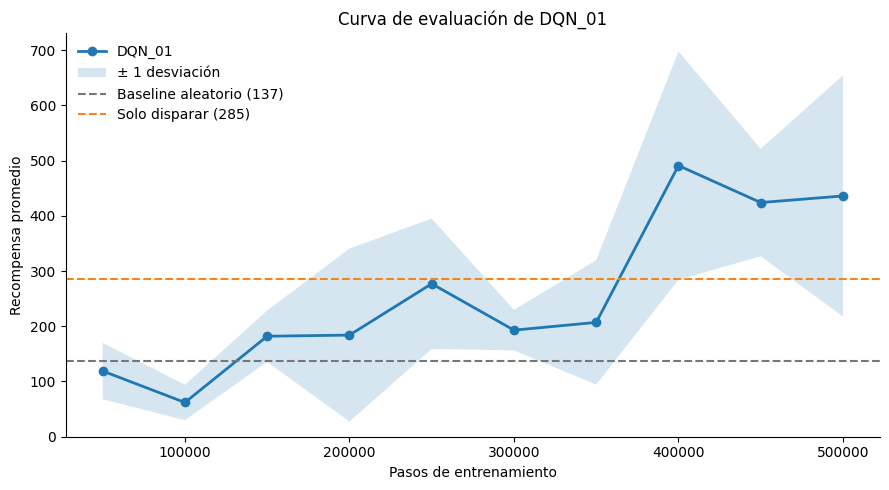

Curva guardada: /content/drive/MyDrive/CC3092/pry2/results/DQN_01_full/curva_evaluacion.png
Existe: True


In [ ]:
import matplotlib.pyplot as plt

ruta_evaluaciones = (
    PROYECTO
    / "results"
    / "DQN_01_full"
    / "evaluations.npz"
)

datos_evaluacion = np.load(ruta_evaluaciones)

timesteps = datos_evaluacion["timesteps"]
recompensas = datos_evaluacion["results"]

promedios = recompensas.mean(axis=1)
desviaciones = recompensas.std(axis=1)

tabla_curva = pd.DataFrame({
    "timesteps": timesteps,
    "recompensa_promedio": promedios,
    "desviacion": desviaciones,
})

display(tabla_curva)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    timesteps,
    promedios,
    marker="o",
    linewidth=2,
    label="DQN_01",
)

ax.fill_between(
    timesteps,
    promedios - desviaciones,
    promedios + desviaciones,
    alpha=0.18,
    label="± 1 desviación",
)

ax.axhline(
    137,
    linestyle="--",
    color="#777777",
    label="Baseline aleatorio (137)",
)

ax.axhline(
    285,
    linestyle="--",
    color="#F58518",
    label="Solo disparar (285)",
)

ax.set_title("Curva de evaluación de DQN_01")
ax.set_xlabel("Pasos de entrenamiento")
ax.set_ylabel("Recompensa promedio")
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()

ruta_curva = (
    PROYECTO
    / "results"
    / "DQN_01_full"
    / "curva_evaluacion.png"
)

fig.savefig(ruta_curva, dpi=180, bbox_inches="tight")
plt.show()

print("Curva guardada:", ruta_curva)
print("Existe:", ruta_curva.exists())

### Análisis de la iteración DQN_01

La recompensa de evaluación no creció de forma monotónica, lo cual es esperable en aprendizaje por refuerzo. Durante las primeras 350,000 interacciones, el agente mostró resultados inestables y generalmente inferiores al baseline de solo disparar.

A partir de 400,000 pasos se observó una mejora importante: la recompensa promedio de evaluación alcanzó 491 puntos. En la evaluación formal con semillas fijas, el modelo final de 500,000 pasos obtuvo un promedio de 436 y un máximo de 635, superando el baseline de solo disparar, cuyo promedio fue 285.

La desviación estándar continuó siendo alta, lo que indica que el comportamiento aprendido todavía depende considerablemente de las condiciones iniciales del episodio. La curva tampoco muestra una estabilización definitiva al finalizar el entrenamiento, por lo que aumentar el número de pasos resulta justificado.

Para la siguiente iteración se utilizará una configuración más cercana a la recomendada para Atari: mayor período inicial de recopilación de experiencias, actualizaciones más frecuentes de la red objetivo, epsilon final más bajo y un entrenamiento considerablemente más largo.

In [ ]:
CONFIG_DQN_02 = {
    "id_experimento": "DQN_02_atari",
    "policy": "CnnPolicy",
    "total_timesteps": 2_000_000,
    "learning_rate": 1e-4,
    "buffer_size": 100_000,
    "learning_starts": 100_000,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.10,
    "exploration_initial_eps": 1.0,
    "exploration_final_eps": 0.01,
    "max_grad_norm": 10.0,
    "optimize_memory_usage": True,
    "reward_clipping": True,
    "seed": 42,
}

carpeta_resultados_dqn02 = (
    PROYECTO / "results" / CONFIG_DQN_02["id_experimento"]
)
carpeta_resultados_dqn02.mkdir(parents=True, exist_ok=True)

ruta_config_dqn02 = (
    carpeta_resultados_dqn02 / "configuracion_experimento.json"
)

ruta_config_dqn02.write_text(
    json.dumps(CONFIG_DQN_02, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

comparacion_config = pd.DataFrame({
    "Parámetro": [
        "total_timesteps",
        "learning_starts",
        "target_update_interval",
        "exploration_fraction",
        "exploration_final_eps",
    ],
    "DQN_01": [
        500_000,
        20_000,
        10_000,
        0.20,
        0.05,
    ],
    "DQN_02": [
        CONFIG_DQN_02["total_timesteps"],
        CONFIG_DQN_02["learning_starts"],
        CONFIG_DQN_02["target_update_interval"],
        CONFIG_DQN_02["exploration_fraction"],
        CONFIG_DQN_02["exploration_final_eps"],
    ],
})

display(comparacion_config)

print("Configuración guardada:", ruta_config_dqn02)
print("Existe:", ruta_config_dqn02.exists())

,Parámetro,DQN_01,DQN_02
0,total_timesteps,500000.00,2000000.00
1,learning_starts,20000.00,100000.00
2,target_update_interval,10000.00,1000.00
3,exploration_fraction,0.20,0.10
4,exploration_final_eps,0.05,0.01


Configuración guardada: /content/drive/MyDrive/CC3092/pry2/results/DQN_02_atari/configuracion_experimento.json
Existe: True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gc

del modelo_mejor_dqn01
del modelo_final_dqn01

gc.collect()
torch.cuda.empty_cache()

from stable_baselines3.common.monitor import Monitor


class ClipRewardEnv(gym.RewardWrapper):
    """Entrega al agente recompensas de -1, 0 o 1."""

    def reward(self, reward):
        return float(np.sign(reward))


def crear_entorno_entrenamiento(seed, nombre_log):
    env = crear_entorno_procesado()

    env.reset(seed=seed)
    env.action_space.seed(seed)

    # Registra la recompensa original.
    env = Monitor(
        env,
        filename=str(PROYECTO / "logs" / nombre_log),
    )

    # El DQN recibe la recompensa recortada.
    env = ClipRewardEnv(env)

    return env


env_prueba_dqn02 = crear_entorno_entrenamiento(
    seed=CONFIG_DQN_02["seed"],
    nombre_log="DQN_02_prueba",
)

observacion, _ = env_prueba_dqn02.reset(
    seed=CONFIG_DQN_02["seed"]
)

print("Memoria de DQN_01 liberada")
print("Observación:", np.asarray(observacion).shape)
print("Acciones:", env_prueba_dqn02.action_space)
print("Wrapper:", type(env_prueba_dqn02).__name__)

env_prueba_dqn02.close()

Memoria de DQN_01 liberada
Observación: (4, 84, 84)
Acciones: Discrete(6)
Wrapper: ClipRewardEnv


In [ ]:
from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback,
    EvalCallback,
)

ID_DQN02 = CONFIG_DQN_02["id_experimento"]

carpeta_checkpoints_dqn02 = (
    PROYECTO / "checkpoints" / ID_DQN02
)
carpeta_modelos_dqn02 = (
    PROYECTO / "models" / ID_DQN02
)
carpeta_resultados_dqn02 = (
    PROYECTO / "results" / ID_DQN02
)

for carpeta in [
    carpeta_checkpoints_dqn02,
    carpeta_modelos_dqn02,
    carpeta_resultados_dqn02,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

env_entrenamiento_dqn02 = crear_entorno_entrenamiento(
    seed=CONFIG_DQN_02["seed"],
    nombre_log=f"{ID_DQN02}_train",
)

modelo_dqn02 = DQN(
    policy=CONFIG_DQN_02["policy"],
    env=env_entrenamiento_dqn02,
    learning_rate=CONFIG_DQN_02["learning_rate"],
    buffer_size=CONFIG_DQN_02["buffer_size"],
    learning_starts=CONFIG_DQN_02["learning_starts"],
    batch_size=CONFIG_DQN_02["batch_size"],
    gamma=CONFIG_DQN_02["gamma"],
    train_freq=CONFIG_DQN_02["train_freq"],
    gradient_steps=CONFIG_DQN_02["gradient_steps"],
    target_update_interval=CONFIG_DQN_02["target_update_interval"],
    exploration_fraction=CONFIG_DQN_02["exploration_fraction"],
    exploration_initial_eps=CONFIG_DQN_02["exploration_initial_eps"],
    exploration_final_eps=CONFIG_DQN_02["exploration_final_eps"],
    max_grad_norm=CONFIG_DQN_02["max_grad_norm"],
    optimize_memory_usage=CONFIG_DQN_02["optimize_memory_usage"],
    replay_buffer_kwargs={
        "handle_timeout_termination": False,
    },
    tensorboard_log=str(PROYECTO / "logs" / "tensorboard"),
    seed=CONFIG_DQN_02["seed"],
    device="cuda",
    verbose=1,
)

env_evaluacion_dqn02 = crear_entorno_procesado()
env_evaluacion_dqn02.reset(seed=100)
env_evaluacion_dqn02 = Monitor(env_evaluacion_dqn02)

checkpoint_dqn02 = CheckpointCallback(
    save_freq=100_000,
    save_path=str(carpeta_checkpoints_dqn02),
    name_prefix="dqn02_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False,
)

evaluacion_dqn02 = EvalCallback(
    env_evaluacion_dqn02,
    best_model_save_path=str(carpeta_modelos_dqn02),
    log_path=str(carpeta_resultados_dqn02),
    eval_freq=100_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
)

callbacks_dqn02 = CallbackList([
    checkpoint_dqn02,
    evaluacion_dqn02,
])

print("\nDQN_02 preparado")
print("Dispositivo:", modelo_dqn02.device)
print("Pasos:", CONFIG_DQN_02["total_timesteps"])
print("Checkpoint cada:", 100_000)
print("Evaluación cada:", 100_000)

Using cuda device
Wrapping the env in a DummyVecEnv.

DQN_02 preparado
Dispositivo: cuda
Pasos: 2000000
Checkpoint cada: 100000
Evaluación cada: 100000


In [ ]:
import time
from datetime import datetime, timezone

inicio_dqn02 = time.time()
fecha_inicio_dqn02 = datetime.now(timezone.utc).isoformat()

modelo_dqn02.learn(
    total_timesteps=CONFIG_DQN_02["total_timesteps"],
    callback=callbacks_dqn02,
    log_interval=50,
    tb_log_name=ID_DQN02,
    reset_num_timesteps=True,
    progress_bar=True,
)

duracion_dqn02 = time.time() - inicio_dqn02

ruta_modelo_final_dqn02 = (
    carpeta_modelos_dqn02 / "modelo_final"
)

modelo_dqn02.save(ruta_modelo_final_dqn02)

registro_dqn02 = {
    "id_experimento": ID_DQN02,
    "estado": "completado",
    "fecha_inicio_utc": fecha_inicio_dqn02,
    "duracion_segundos": duracion_dqn02,
    "duracion_minutos": duracion_dqn02 / 60,
    "timesteps": modelo_dqn02.num_timesteps,
    "modelo_final": str(ruta_modelo_final_dqn02) + ".zip",
    "configuracion": CONFIG_DQN_02,
}

ruta_registro_dqn02 = (
    carpeta_resultados_dqn02 / "registro_entrenamiento.json"
)

ruta_registro_dqn02.write_text(
    json.dumps(registro_dqn02, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("\nEntrenamiento DQN_02 finalizado")
print("Pasos:", modelo_dqn02.num_timesteps)
print("Duración en minutos:", round(duracion_dqn02 / 60, 2))
print("Modelo:", str(ruta_modelo_final_dqn02) + ".zip")
print("Registro:", ruta_registro_dqn02)

Logging to /content/drive/MyDrive/CC3092/pry2/logs/tensorboard/DQN_02_atari_1


Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 494      |
|    ep_rew_mean      | 148      |
|    exploration_rate | 0.878    |
| time/               |          |
|    episodes         | 50       |
|    fps              | 737      |
|    time_elapsed     | 33       |
|    total_timesteps  | 24680    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 517      |
|    ep_rew_mean      | 164      |
|    exploration_rate | 0.744    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 729      |
|    time_elapsed     | 70       |
|    total_timesteps  | 51676    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 535      |
|    ep_rew_mean      | 168      |
|    exploration_rate | 0.613    |
| time/               |          |
|    episodes       

Eval num_timesteps=100000, episode_reward=0.00 +/- 0.00

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 715      |
|    mean_reward      | 518      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 1900000  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0746   |
|    n_updates        | 449999   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 783      |
|    ep_rew_mean      | 494      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 2800     |
|    fps              | 260      |
|    time_elapsed     | 7378     |
|    total_timesteps  | 1919403  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0148   |
|    n_updates        | 454850   |
----------------------------------
--------------------

Eval num_timesteps=2000000, episode_reward=510.00 +/- 177.96

Episode length: 866.80 +/- 134.89

----------------------------------
| eval/               |          |
|    mean_ep_length   | 867      |
|    mean_reward      | 510      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 2000000  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0101   |
|    n_updates        | 474999   |
----------------------------------



Entrenamiento DQN_02 finalizado
Pasos: 2000000
Duración en minutos: 128.11
Modelo: /content/drive/MyDrive/CC3092/pry2/models/DQN_02_atari/modelo_final.zip
Registro: /content/drive/MyDrive/CC3092/pry2/results/DQN_02_atari/registro_entrenamiento.json


In [ ]:
from pathlib import Path

PROYECTO = Path("/content/drive/MyDrive/CC3092/pry2")
ID_DQN02 = "DQN_02_atari"

carpetas_dqn02 = {
    "checkpoints": PROYECTO / "checkpoints" / ID_DQN02,
    "modelos": PROYECTO / "models" / ID_DQN02,
    "resultados": PROYECTO / "results" / ID_DQN02,
}

for tipo, carpeta in carpetas_dqn02.items():
    print(f"\n{tipo.upper()}: {carpeta}")
    print("Existe:", carpeta.exists())

    if carpeta.exists():
        archivos = sorted(
            archivo
            for archivo in carpeta.rglob("*")
            if archivo.is_file()
        )

        if not archivos:
            print("- Sin archivos")

        for archivo in archivos:
            tamaño_mb = archivo.stat().st_size / (1024 ** 2)
            print(f"- {archivo.name}: {tamaño_mb:.2f} MB")


CHECKPOINTS: /content/drive/MyDrive/CC3092/pry2/checkpoints/DQN_02_atari
Existe: True
- dqn02_space_invaders_1000000_steps.zip: 25.99 MB
- dqn02_space_invaders_100000_steps.zip: 13.12 MB
- dqn02_space_invaders_1100000_steps.zip: 25.99 MB
- dqn02_space_invaders_1200000_steps.zip: 25.99 MB
- dqn02_space_invaders_1300000_steps.zip: 25.99 MB
- dqn02_space_invaders_1400000_steps.zip: 25.99 MB
- dqn02_space_invaders_1500000_steps.zip: 25.99 MB
- dqn02_space_invaders_1600000_steps.zip: 25.99 MB
- dqn02_space_invaders_1700000_steps.zip: 25.99 MB
- dqn02_space_invaders_1800000_steps.zip: 25.99 MB
- dqn02_space_invaders_1900000_steps.zip: 25.99 MB
- dqn02_space_invaders_2000000_steps.zip: 25.99 MB
- dqn02_space_invaders_200000_steps.zip: 25.99 MB
- dqn02_space_invaders_300000_steps.zip: 25.99 MB
- dqn02_space_invaders_400000_steps.zip: 25.99 MB
- dqn02_space_invaders_500000_steps.zip: 25.99 MB
- dqn02_space_invaders_600000_steps.zip: 25.99 MB
- dqn02_space_invaders_700000_steps.zip: 25.99 MB
- 

In [ ]:
import json
import numpy as np
import pandas as pd

carpeta_resultados_dqn02 = (
    PROYECTO / "results" / ID_DQN02
)

ruta_registro_dqn02 = (
    carpeta_resultados_dqn02 / "registro_entrenamiento.json"
)

ruta_evaluaciones_dqn02 = (
    carpeta_resultados_dqn02 / "evaluations.npz"
)

registro_dqn02 = json.loads(
    ruta_registro_dqn02.read_text(encoding="utf-8")
)

datos_dqn02 = np.load(ruta_evaluaciones_dqn02)

tabla_evaluaciones_dqn02 = pd.DataFrame({
    "timesteps": datos_dqn02["timesteps"],
    "recompensa_promedio": datos_dqn02["results"].mean(axis=1),
    "desviacion": datos_dqn02["results"].std(axis=1),
    "recompensa_maxima": datos_dqn02["results"].max(axis=1),
})

print("Estado:", registro_dqn02.get("estado"))
print("Timesteps:", registro_dqn02.get("timesteps"))
print("Duración en minutos:", registro_dqn02.get("duracion_minutos"))
print("Modelo final:", registro_dqn02.get("modelo_final"))

print("\nEvaluaciones:")
display(tabla_evaluaciones_dqn02)

mejor_fila = tabla_evaluaciones_dqn02.loc[
    tabla_evaluaciones_dqn02["recompensa_promedio"].idxmax()
]

print("\nMejor evaluación:")
print(mejor_fila)

Estado: completado
Timesteps: 2000000
Duración en minutos: 128.10941061576207
Modelo final: /content/drive/MyDrive/CC3092/pry2/models/DQN_02_atari/modelo_final.zip

Evaluaciones:


,timesteps,recompensa_promedio,desviacion,recompensa_maxima
0,100000,0.0,0.000000,0.0
1,200000,103.0,81.890170,230.0
2,300000,285.0,0.000000,285.0
3,400000,179.0,58.770741,260.0
4,500000,300.0,78.485667,385.0
5,600000,293.0,39.191836,340.0
6,700000,88.0,31.240999,120.0
7,800000,380.0,199.072851,690.0
8,900000,475.0,151.095996,690.0
9,1000000,630.0,128.140548,805.0



Mejor evaluación:
timesteps              1.700000e+06
recompensa_promedio    6.800000e+02
desviacion             8.043631e+01
recompensa_maxima      7.750000e+02
Name: 16, dtype: float64


In [ ]:
import torch
from stable_baselines3 import DQN

carpeta_modelos_dqn02 = (
    PROYECTO / "models" / ID_DQN02
)

ruta_mejor_dqn02 = carpeta_modelos_dqn02 / "best_model.zip"
ruta_final_dqn02 = carpeta_modelos_dqn02 / "modelo_final.zip"

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

modelo_mejor_dqn02 = DQN.load(
    ruta_mejor_dqn02,
    device=dispositivo,
)

modelo_final_dqn02 = DQN.load(
    ruta_final_dqn02,
    device=dispositivo,
)

print("Dispositivo:", dispositivo)

print("\nMejor modelo DQN_02:")
print("- existe:", ruta_mejor_dqn02.exists())
print("- pasos:", modelo_mejor_dqn02.num_timesteps)

print("\nModelo final DQN_02:")
print("- existe:", ruta_final_dqn02.exists())
print("- pasos:", modelo_final_dqn02.num_timesteps)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dispositivo: cuda

Mejor modelo DQN_02:
- existe: True
- pasos: 1700000

Modelo final DQN_02:
- existe: True
- pasos: 2000000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gymnasium as gym
import ale_py

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

gym.register_envs(ale_py)

CONFIG_ENTORNO = {
    "env_id": "ALE/SpaceInvaders-v5",
    "base_frameskip": 1,
    "repeat_action_probability": 0.25,
    "full_action_space": False,
    "noop_max": 30,
    "frame_skip": 4,
    "screen_size": 84,
    "grayscale_obs": True,
    "scale_obs": False,
    "terminal_on_life_loss": False,
    "stack_size": 4,
}


def crear_entorno_procesado():
    env = gym.make(
        CONFIG_ENTORNO["env_id"],
        frameskip=CONFIG_ENTORNO["base_frameskip"],
        repeat_action_probability=CONFIG_ENTORNO[
            "repeat_action_probability"
        ],
        full_action_space=CONFIG_ENTORNO["full_action_space"],
    )

    env = AtariPreprocessing(
        env,
        noop_max=CONFIG_ENTORNO["noop_max"],
        frame_skip=CONFIG_ENTORNO["frame_skip"],
        screen_size=CONFIG_ENTORNO["screen_size"],
        grayscale_obs=CONFIG_ENTORNO["grayscale_obs"],
        scale_obs=CONFIG_ENTORNO["scale_obs"],
        terminal_on_life_loss=CONFIG_ENTORNO[
            "terminal_on_life_loss"
        ],
    )

    return FrameStackObservation(
        env,
        stack_size=CONFIG_ENTORNO["stack_size"],
    )


def evaluar_modelo_sb3(
    modelo,
    nombre_modelo,
    semillas,
    max_steps=30000,
):
    registros = []

    for episodio, semilla in enumerate(semillas, start=1):
        env = crear_entorno_procesado()

        try:
            observacion, _ = env.reset(seed=semilla)
            recompensa_total = 0.0
            pasos = 0
            terminated = False
            truncated = False

            while not (terminated or truncated) and pasos < max_steps:
                accion, _ = modelo.predict(
                    np.asarray(observacion),
                    deterministic=True,
                )

                accion = int(np.asarray(accion).item())

                observacion, recompensa, terminated, truncated, _ = env.step(
                    accion
                )

                recompensa_total += float(recompensa)
                pasos += 1
        finally:
            env.close()

        registros.append({
            "modelo": nombre_modelo,
            "episodio": episodio,
            "seed": semilla,
            "pasos": pasos,
            "recompensa_total": recompensa_total,
        })

        print(
            f"{nombre_modelo} | episodio {episodio} | "
            f"recompensa={recompensa_total} | pasos={pasos}"
        )

    resultados = pd.DataFrame(registros)

    resumen = {
        "modelo": nombre_modelo,
        "episodios": len(resultados),
        "promedio": float(resultados["recompensa_total"].mean()),
        "maximo": float(resultados["recompensa_total"].max()),
        "minimo": float(resultados["recompensa_total"].min()),
        "desviacion": float(
            resultados["recompensa_total"].std(ddof=0)
        ),
    }

    return resultados, resumen


print("Entorno y evaluación recuperados")

Entorno y evaluación recuperados


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
SEMILLAS_EVALUACION = [100, 101, 102, 103, 104]

resultados_mejor_dqn02, resumen_mejor_dqn02 = evaluar_modelo_sb3(
    modelo=modelo_mejor_dqn02,
    nombre_modelo="DQN_02_best_1700k",
    semillas=SEMILLAS_EVALUACION,
)

print("\nEvaluando modelo final de 2M...\n")

resultados_final_dqn02, resumen_final_dqn02 = evaluar_modelo_sb3(
    modelo=modelo_final_dqn02,
    nombre_modelo="DQN_02_final_2000k",
    semillas=SEMILLAS_EVALUACION,
)

comparacion_dqn02 = pd.DataFrame([
    resumen_mejor_dqn02,
    resumen_final_dqn02,
])

print("\nComparación formal:")
display(comparacion_dqn02)

DQN_02_best_1700k | episodio 1 | recompensa=490.0 | pasos=804
DQN_02_best_1700k | episodio 2 | recompensa=510.0 | pasos=1030
DQN_02_best_1700k | episodio 3 | recompensa=600.0 | pasos=939
DQN_02_best_1700k | episodio 4 | recompensa=105.0 | pasos=355
DQN_02_best_1700k | episodio 5 | recompensa=400.0 | pasos=888

Evaluando modelo final de 2M...

DQN_02_final_2000k | episodio 1 | recompensa=70.0 | pasos=276
DQN_02_final_2000k | episodio 2 | recompensa=575.0 | pasos=880
DQN_02_final_2000k | episodio 3 | recompensa=275.0 | pasos=537
DQN_02_final_2000k | episodio 4 | recompensa=115.0 | pasos=302
DQN_02_final_2000k | episodio 5 | recompensa=495.0 | pasos=866

Comparación formal:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,episodios,promedio,maximo,minimo,desviacion
0,DQN_02_best_1700k,5,421.0,600.0,105.0,170.305608
1,DQN_02_final_2000k,5,306.0,575.0,70.0,200.609073


In [ ]:
resultados_formales_dqn02 = pd.concat(
    [resultados_mejor_dqn02, resultados_final_dqn02],
    ignore_index=True,
)

resumen_formal_dqn02 = {
    "semillas": SEMILLAS_EVALUACION,
    "mejor_checkpoint_1700k": resumen_mejor_dqn02,
    "modelo_final_2000k": resumen_final_dqn02,
    "comparacion": {
        "DQN_01_final_promedio": 436.0,
        "DQN_01_final_maximo": 635.0,
        "baseline_solo_disparar": 285.0,
    },
}

ruta_episodios_dqn02 = (
    carpeta_resultados_dqn02 / "evaluacion_formal_episodios.csv"
)

ruta_resumen_dqn02 = (
    carpeta_resultados_dqn02 / "evaluacion_formal_resumen.json"
)

resultados_formales_dqn02.to_csv(
    ruta_episodios_dqn02,
    index=False,
)

ruta_resumen_dqn02.write_text(
    json.dumps(
        resumen_formal_dqn02,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Evaluación guardada:")
print("-", ruta_episodios_dqn02)
print("-", ruta_resumen_dqn02)
print("CSV existe:", ruta_episodios_dqn02.exists())
print("JSON existe:", ruta_resumen_dqn02.exists())

Evaluación guardada:
- /content/drive/MyDrive/CC3092/pry2/results/DQN_02_atari/evaluacion_formal_episodios.csv
- /content/drive/MyDrive/CC3092/pry2/results/DQN_02_atari/evaluacion_formal_resumen.json
CSV existe: True
JSON existe: True


In [ ]:
%pip install -q "sb3-contrib==2.9.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 3.8 MB/s eta 0:00:00


In [ ]:
import sb3_contrib
from sb3_contrib import QRDQN

print("sb3-contrib:", sb3_contrib.__version__)
print("QR-DQN disponible:", QRDQN)

sb3-contrib: 2.9.0
QR-DQN disponible: <class 'sb3_contrib.qrdqn.qrdqn.QRDQN'>


In [ ]:
import gc
import json
import torch
from pathlib import Path

# Liberar los modelos DQN anteriores de la memoria
for nombre_variable in [
    "modelo_mejor_dqn02",
    "modelo_final_dqn02",
    "modelo_mejor_dqn01",
    "modelo_final_dqn01",
]:
    if nombre_variable in globals():
        del globals()[nombre_variable]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

ID_QRDQN = "QRDQN_01"

carpeta_checkpoints_qrdqn = (
    PROYECTO / "checkpoints" / ID_QRDQN
)
carpeta_modelos_qrdqn = (
    PROYECTO / "models" / ID_QRDQN
)
carpeta_resultados_qrdqn = (
    PROYECTO / "results" / ID_QRDQN
)
carpeta_logs_qrdqn = (
    PROYECTO / "logs" / "tensorboard"
)

for carpeta in [
    carpeta_checkpoints_qrdqn,
    carpeta_modelos_qrdqn,
    carpeta_resultados_qrdqn,
    carpeta_logs_qrdqn,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

CONFIG_QRDQN = {
    "id_experimento": ID_QRDQN,
    "algoritmo": "QR-DQN",
    "policy": "CnnPolicy",
    "timesteps_prueba_velocidad": 200_000,
    "limite_entrenamiento_horas": 30,
    "learning_rate": 1e-4,
    "buffer_size": 100_000,
    "learning_starts": 100_000,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.10,
    "exploration_initial_eps": 1.0,
    "exploration_final_eps": 0.01,
    "max_grad_norm": 10,
    "n_quantiles": 200,
    "seed": 42,
    "reward_clipping": True,
}

print("Experimento:", ID_QRDQN)
print("GPU:", torch.cuda.get_device_name(0))
print("Prueba de velocidad:", CONFIG_QRDQN["timesteps_prueba_velocidad"])
print("Cuantiles:", CONFIG_QRDQN["n_quantiles"])
print("Checkpoints:", carpeta_checkpoints_qrdqn)
print("Modelos:", carpeta_modelos_qrdqn)
print("Resultados:", carpeta_resultados_qrdqn)

Experimento: QRDQN_01
GPU: Tesla T4
Prueba de velocidad: 200000
Cuantiles: 200
Checkpoints: /content/drive/MyDrive/CC3092/pry2/checkpoints/QRDQN_01
Modelos: /content/drive/MyDrive/CC3092/pry2/models/QRDQN_01
Resultados: /content/drive/MyDrive/CC3092/pry2/results/QRDQN_01


In [ ]:
import numpy as np
import gymnasium as gym
from stable_baselines3.common.monitor import Monitor


class ClipRewardEnv(gym.RewardWrapper):
    def reward(self, reward):
        return float(np.sign(reward))


def crear_entorno_entrenamiento_qrdqn(seed=42):
    env = crear_entorno_procesado()

    env.reset(seed=seed)
    env.action_space.seed(seed)

    ruta_monitor = PROYECTO / "logs" / f"{ID_QRDQN}_monitor"

    # Monitor registra la recompensa original
    env = Monitor(env, filename=str(ruta_monitor))

    # QR-DQN recibe la recompensa recortada
    env = ClipRewardEnv(env)

    return env


entorno_qrdqn = crear_entorno_entrenamiento_qrdqn(
    seed=CONFIG_QRDQN["seed"]
)

observacion, info = entorno_qrdqn.reset(
    seed=CONFIG_QRDQN["seed"]
)

print("Observación:", observacion.shape, observacion.dtype)
print("Acciones:", entorno_qrdqn.action_space)
print("Wrapper exterior:", type(entorno_qrdqn).__name__)
print("Wrapper de métricas:", type(entorno_qrdqn.env).__name__)

Observación: (4, 84, 84) uint8
Acciones: Discrete(6)
Wrapper exterior: ClipRewardEnv
Wrapper de métricas: Monitor


In [ ]:
modelo_qrdqn_prueba = QRDQN(
    policy=CONFIG_QRDQN["policy"],
    env=entorno_qrdqn,

    learning_rate=CONFIG_QRDQN["learning_rate"],
    buffer_size=CONFIG_QRDQN["buffer_size"],
    learning_starts=CONFIG_QRDQN["learning_starts"],
    batch_size=CONFIG_QRDQN["batch_size"],
    gamma=CONFIG_QRDQN["gamma"],

    train_freq=CONFIG_QRDQN["train_freq"],
    gradient_steps=CONFIG_QRDQN["gradient_steps"],
    target_update_interval=CONFIG_QRDQN[
        "target_update_interval"
    ],

    exploration_fraction=CONFIG_QRDQN[
        "exploration_fraction"
    ],
    exploration_initial_eps=CONFIG_QRDQN[
        "exploration_initial_eps"
    ],
    exploration_final_eps=CONFIG_QRDQN[
        "exploration_final_eps"
    ],

    max_grad_norm=CONFIG_QRDQN["max_grad_norm"],
    optimize_memory_usage=True,
    replay_buffer_kwargs={
        "handle_timeout_termination": False
    },

    policy_kwargs={
        "n_quantiles": CONFIG_QRDQN["n_quantiles"]
    },

    tensorboard_log=str(carpeta_logs_qrdqn),
    seed=CONFIG_QRDQN["seed"],
    device="cuda",
    verbose=1,
)

print("\nModelo QR-DQN creado")
print("Dispositivo:", modelo_qrdqn_prueba.device)
print("Política:", type(modelo_qrdqn_prueba.policy).__name__)
print(
    "Cuantiles:",
    modelo_qrdqn_prueba.policy.n_quantiles
)
print(
    "Pasos de prueba:",
    CONFIG_QRDQN["timesteps_prueba_velocidad"]
)

Using cuda device
Wrapping the env in a DummyVecEnv.

Modelo QR-DQN creado
Dispositivo: cuda
Política: CnnPolicy
Cuantiles: 200
Pasos de prueba: 200000


In [ ]:
from stable_baselines3.common.callbacks import (
    CheckpointCallback,
    EvalCallback,
    CallbackList,
)

carpeta_smoke_checkpoints = (
    carpeta_checkpoints_qrdqn / "smoke_test"
)
carpeta_smoke_modelos = (
    carpeta_modelos_qrdqn / "smoke_test"
)
carpeta_smoke_resultados = (
    carpeta_resultados_qrdqn / "smoke_test"
)

for carpeta in [
    carpeta_smoke_checkpoints,
    carpeta_smoke_modelos,
    carpeta_smoke_resultados,
]:
    carpeta.mkdir(parents=True, exist_ok=True)


# Evaluación con recompensas originales, sin clipping
entorno_eval_qrdqn = Monitor(
    crear_entorno_procesado()
)
entorno_eval_qrdqn.reset(seed=CONFIG_QRDQN["seed"])
entorno_eval_qrdqn.action_space.seed(
    CONFIG_QRDQN["seed"]
)


callback_checkpoint_smoke = CheckpointCallback(
    save_freq=100_000,
    save_path=str(carpeta_smoke_checkpoints),
    name_prefix="qrdqn_smoke",
    save_replay_buffer=False,
)


callback_evaluacion_smoke = EvalCallback(
    entorno_eval_qrdqn,
    best_model_save_path=str(carpeta_smoke_modelos),
    log_path=str(carpeta_smoke_resultados),
    eval_freq=100_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
)


callbacks_smoke = CallbackList([
    callback_checkpoint_smoke,
    callback_evaluacion_smoke,
])


print("Callbacks configurados")
print("Evaluaciones: cada 100000 pasos")
print("Checkpoints:", carpeta_smoke_checkpoints)
print("Mejor modelo:", carpeta_smoke_modelos)
print("Resultados:", carpeta_smoke_resultados)

Callbacks configurados
Evaluaciones: cada 100000 pasos
Checkpoints: /content/drive/MyDrive/CC3092/pry2/checkpoints/QRDQN_01/smoke_test
Mejor modelo: /content/drive/MyDrive/CC3092/pry2/models/QRDQN_01/smoke_test
Resultados: /content/drive/MyDrive/CC3092/pry2/results/QRDQN_01/smoke_test


In [ ]:
import time
from stable_baselines3.common.callbacks import (
    BaseCallback,
    CallbackList,
)


class MedirVelocidadCallback(BaseCallback):
    def __init__(
        self,
        inicio_aprendizaje=100_000,
        final_prueba=200_000,
    ):
        super().__init__()
        self.inicio_aprendizaje_paso = inicio_aprendizaje
        self.final_prueba_paso = final_prueba

        self.tiempo_inicio_total = None
        self.tiempo_inicio_aprendizaje = None
        self.tiempo_final_prueba = None

    def _on_training_start(self):
        self.tiempo_inicio_total = time.perf_counter()

    def _on_step(self):
        if (
            self.tiempo_inicio_aprendizaje is None
            and self.num_timesteps
            >= self.inicio_aprendizaje_paso
        ):
            self.tiempo_inicio_aprendizaje = (
                time.perf_counter()
            )

        if (
            self.tiempo_final_prueba is None
            and self.num_timesteps
            >= self.final_prueba_paso
        ):
            self.tiempo_final_prueba = time.perf_counter()

        return True


callback_tiempo = MedirVelocidadCallback()

callbacks_smoke = CallbackList([
    callback_tiempo,
    callback_checkpoint_smoke,
    callback_evaluacion_smoke,
])


modelo_qrdqn_prueba.learn(
    total_timesteps=CONFIG_QRDQN[
        "timesteps_prueba_velocidad"
    ],
    callback=callbacks_smoke,
    tb_log_name=f"{ID_QRDQN}_smoke",
    progress_bar=True,
)


ruta_modelo_smoke = (
    carpeta_smoke_modelos / "modelo_smoke_final"
)
modelo_qrdqn_prueba.save(str(ruta_modelo_smoke))


segundos_iniciales = (
    callback_tiempo.tiempo_inicio_aprendizaje
    - callback_tiempo.tiempo_inicio_total
)

segundos_entrenando = (
    callback_tiempo.tiempo_final_prueba
    - callback_tiempo.tiempo_inicio_aprendizaje
)

fps_entrenamiento = 100_000 / segundos_entrenando


def estimar_horas(total_timesteps):
    segundos = segundos_iniciales + (
        total_timesteps - 100_000
    ) / fps_entrenamiento

    return segundos / 3600


print("\nPrueba QR-DQN terminada")
print(
    "Tiempo primeros 100k:",
    round(segundos_iniciales / 60, 2),
    "minutos",
)
print(
    "Tiempo segundos 100k:",
    round(segundos_entrenando / 60, 2),
    "minutos",
)
print(
    "Velocidad durante aprendizaje:",
    round(fps_entrenamiento, 2),
    "pasos/segundo",
)
print(
    "Estimación para 5M:",
    round(estimar_horas(5_000_000), 2),
    "horas",
)
print(
    "Estimación para 10M:",
    round(estimar_horas(10_000_000), 2),
    "horas",
)
print(
    "Modelo guardado en:",
    ruta_modelo_smoke,
)

Logging to /content/drive/MyDrive/CC3092/pry2/logs/tensorboard/QRDQN_01_smoke_1


Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 607      |
|    ep_rew_mean      | 181      |
|    exploration_rate | 0.88     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 456      |
|    time_elapsed     | 5        |
|    total_timesteps  | 2427     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 596      |
|    ep_rew_mean      | 177      |
|    exploration_rate | 0.764    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 565      |
|    time_elapsed     | 8        |
|    total_timesteps  | 4764     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 567      |
|    ep_rew_mean      | 165      |
|    exploration_rate | 0.663    |
| time/               |          |
|    episodes       

Eval num_timesteps=100000, episode_reward=285.00 +/- 0.00

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 516      |
|    ep_rew_mean      | 149      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 196      |
|    fps              | 586      |
|    time_elapsed     | 172      |
|    total_timesteps  | 101189   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.219    |
|    n_updates        | 297      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 531      |
|    ep_rew_mean      | 151      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 200      |
|    fps              | 553      |
|    time_elapsed     | 189      |
|    total_timesteps  | 104732   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.08     |
|    n_updates      

Eval num_timesteps=200000, episode_reward=270.00 +/- 0.00

Episode length: 533.80 +/- 1.72

----------------------------------
| eval/               |          |
|    mean_ep_length   | 534      |
|    mean_reward      | 270      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 200000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.7      |
|    n_updates        | 24999    |
----------------------------------



Prueba QR-DQN terminada
Tiempo primeros 100k: 2.59 minutos
Tiempo segundos 100k: 8.06 minutos
Velocidad durante aprendizaje: 206.66 pasos/segundo
Estimación para 5M: 6.63 horas
Estimación para 10M: 13.35 horas
Modelo guardado en: /content/drive/MyDrive/CC3092/pry2/models/QRDQN_01/smoke_test/modelo_smoke_final


In [ ]:
import gc
import json
import torch

# Cerrar los entornos y liberar el modelo de prueba
entorno_qrdqn.close()
entorno_eval_qrdqn.close()

del modelo_qrdqn_prueba
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


ID_QRDQN_FULL = "QRDQN_01_full_8M"

carpeta_checkpoints_qrdqn_full = (
    PROYECTO
    / "checkpoints"
    / "QRDQN_01"
    / "full_8M"
)

carpeta_modelos_qrdqn_full = (
    PROYECTO
    / "models"
    / "QRDQN_01"
    / "full_8M"
)

carpeta_resultados_qrdqn_full = (
    PROYECTO
    / "results"
    / "QRDQN_01"
    / "full_8M"
)

for carpeta in [
    carpeta_checkpoints_qrdqn_full,
    carpeta_modelos_qrdqn_full,
    carpeta_resultados_qrdqn_full,
]:
    carpeta.mkdir(parents=True, exist_ok=True)


CONFIG_QRDQN_FULL = {
    **CONFIG_QRDQN,
    "id_experimento": ID_QRDQN_FULL,
    "total_timesteps": 8_000_000,
    "checkpoint_freq": 250_000,
    "eval_freq": 250_000,
    "n_eval_episodes": 5,
    "entrenamiento_desde_cero": True,
}


ruta_config_qrdqn_full = (
    carpeta_resultados_qrdqn_full
    / "configuracion_experimento.json"
)

with open(
    ruta_config_qrdqn_full,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        CONFIG_QRDQN_FULL,
        archivo,
        indent=4,
        ensure_ascii=False,
    )


print("Experimento:", ID_QRDQN_FULL)
print("Pasos:", CONFIG_QRDQN_FULL["total_timesteps"])
print(
    "Duración aproximada:",
    round(estimar_horas(8_000_000), 2),
    "horas",
)
print(
    "Evaluación cada:",
    CONFIG_QRDQN_FULL["eval_freq"],
)
print(
    "Checkpoint cada:",
    CONFIG_QRDQN_FULL["checkpoint_freq"],
)
print("Configuración:", ruta_config_qrdqn_full)
print("Existe:", ruta_config_qrdqn_full.exists())

Experimento: QRDQN_01_full_8M
Pasos: 8000000
Duración aproximada: 10.66 horas
Evaluación cada: 250000
Checkpoint cada: 250000
Configuración: /content/drive/MyDrive/CC3092/pry2/results/QRDQN_01/full_8M/configuracion_experimento.json
Existe: True


In [ ]:
# Entorno nuevo para el entrenamiento completo
entorno_qrdqn_full = crear_entorno_entrenamiento_qrdqn(
    seed=CONFIG_QRDQN_FULL["seed"]
)


modelo_qrdqn_full = QRDQN(
    policy=CONFIG_QRDQN_FULL["policy"],
    env=entorno_qrdqn_full,

    learning_rate=CONFIG_QRDQN_FULL["learning_rate"],
    buffer_size=CONFIG_QRDQN_FULL["buffer_size"],
    learning_starts=CONFIG_QRDQN_FULL[
        "learning_starts"
    ],
    batch_size=CONFIG_QRDQN_FULL["batch_size"],
    gamma=CONFIG_QRDQN_FULL["gamma"],

    train_freq=CONFIG_QRDQN_FULL["train_freq"],
    gradient_steps=CONFIG_QRDQN_FULL[
        "gradient_steps"
    ],
    target_update_interval=CONFIG_QRDQN_FULL[
        "target_update_interval"
    ],

    exploration_fraction=CONFIG_QRDQN_FULL[
        "exploration_fraction"
    ],
    exploration_initial_eps=CONFIG_QRDQN_FULL[
        "exploration_initial_eps"
    ],
    exploration_final_eps=CONFIG_QRDQN_FULL[
        "exploration_final_eps"
    ],

    max_grad_norm=CONFIG_QRDQN_FULL[
        "max_grad_norm"
    ],
    optimize_memory_usage=True,
    replay_buffer_kwargs={
        "handle_timeout_termination": False
    },

    policy_kwargs={
        "n_quantiles": CONFIG_QRDQN_FULL[
            "n_quantiles"
        ]
    },

    tensorboard_log=str(carpeta_logs_qrdqn),
    seed=CONFIG_QRDQN_FULL["seed"],
    device="cuda",
    verbose=1,
)


print("\nModelo completo preparado")
print("Modelo:", type(modelo_qrdqn_full).__name__)
print("Dispositivo:", modelo_qrdqn_full.device)
print(
    "Cuantiles:",
    modelo_qrdqn_full.policy.n_quantiles,
)
print(
    "Pasos planificados:",
    CONFIG_QRDQN_FULL["total_timesteps"],
)
print(
    "Exploración llegará a 0.01 aproximadamente en:",
    int(
        CONFIG_QRDQN_FULL["total_timesteps"]
        * CONFIG_QRDQN_FULL["exploration_fraction"]
    ),
    "pasos",
)

Using cuda device
Wrapping the env in a DummyVecEnv.

Modelo completo preparado
Modelo: QRDQN
Dispositivo: cuda
Cuantiles: 200
Pasos planificados: 8000000
Exploración llegará a 0.01 aproximadamente en: 800000 pasos


In [ ]:
import time
import psutil

segundos_activa = time.time() - psutil.boot_time()
horas_activa = segundos_activa / 3600

print(
    "Tiempo activo del entorno:",
    round(horas_activa, 2),
    "horas",
)
print(
    "Tiempo estimado total al finalizar:",
    round(horas_activa + 10.66, 2),
    "horas",
)

Tiempo activo del entorno: 0.24 horas
Tiempo estimado total al finalizar: 10.9 horas


In [ ]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
import gymnasium as gym
import ale_py

from gymnasium.wrappers import (
    AtariPreprocessing,
    FrameStackObservation,
)

from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (
    BaseCallback,
    CheckpointCallback,
    EvalCallback,
    CallbackList,
)

from sb3_contrib import QRDQN


gym.register_envs(ale_py)


PROYECTO = Path(
    "/content/drive/MyDrive/CC3092/pry2"
)

ID_QRDQN_FULL = "QRDQN_01_full_8M"

carpeta_checkpoints_qrdqn_full = (
    PROYECTO
    / "checkpoints"
    / "QRDQN_01"
    / "full_8M"
)

carpeta_modelos_qrdqn_full = (
    PROYECTO
    / "models"
    / "QRDQN_01"
    / "full_8M"
)

carpeta_resultados_qrdqn_full = (
    PROYECTO
    / "results"
    / "QRDQN_01"
    / "full_8M"
)

carpeta_logs_qrdqn = (
    PROYECTO / "logs" / "tensorboard"
)

for carpeta in [
    carpeta_checkpoints_qrdqn_full,
    carpeta_modelos_qrdqn_full,
    carpeta_resultados_qrdqn_full,
    carpeta_logs_qrdqn,
]:
    carpeta.mkdir(parents=True, exist_ok=True)


CONFIG_ENTORNO = {
    "env_id": "ALE/SpaceInvaders-v5",
    "seed": 42,
    "base_frameskip": 1,
    "repeat_action_probability": 0.25,
    "full_action_space": False,
    "noop_max": 30,
    "frame_skip": 4,
    "screen_size": 84,
    "grayscale_obs": True,
    "scale_obs": False,
    "terminal_on_life_loss": False,
    "stack_size": 4,
}


CONFIG_QRDQN_FULL = {
    "id_experimento": ID_QRDQN_FULL,
    "algoritmo": "QR-DQN",
    "policy": "CnnPolicy",
    "total_timesteps": 8_000_000,
    "learning_rate": 1e-4,
    "buffer_size": 100_000,
    "learning_starts": 100_000,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.10,
    "exploration_initial_eps": 1.0,
    "exploration_final_eps": 0.01,
    "max_grad_norm": 10,
    "n_quantiles": 200,
    "seed": 42,
    "reward_clipping": True,
    "checkpoint_freq": 250_000,
    "eval_freq": 250_000,
    "n_eval_episodes": 5,
}


class ClipRewardEnv(gym.RewardWrapper):
    def reward(self, reward):
        return float(np.sign(reward))


def crear_entorno_procesado():
    env = gym.make(
        CONFIG_ENTORNO["env_id"],
        frameskip=CONFIG_ENTORNO["base_frameskip"],
        repeat_action_probability=CONFIG_ENTORNO[
            "repeat_action_probability"
        ],
        full_action_space=CONFIG_ENTORNO[
            "full_action_space"
        ],
    )

    env = AtariPreprocessing(
        env,
        noop_max=CONFIG_ENTORNO["noop_max"],
        frame_skip=CONFIG_ENTORNO["frame_skip"],
        screen_size=CONFIG_ENTORNO["screen_size"],
        terminal_on_life_loss=CONFIG_ENTORNO[
            "terminal_on_life_loss"
        ],
        grayscale_obs=CONFIG_ENTORNO[
            "grayscale_obs"
        ],
        scale_obs=CONFIG_ENTORNO["scale_obs"],
    )

    env = FrameStackObservation(
        env,
        stack_size=CONFIG_ENTORNO["stack_size"],
    )

    return env


def crear_entorno_entrenamiento_qrdqn(seed=42):
    env = crear_entorno_procesado()

    env.reset(seed=seed)
    env.action_space.seed(seed)

    env = Monitor(
        env,
        filename=str(
            PROYECTO
            / "logs"
            / f"{ID_QRDQN_FULL}_monitor"
        ),
    )

    env = ClipRewardEnv(env)

    return env


ruta_configuracion = (
    carpeta_resultados_qrdqn_full
    / "configuracion_experimento.json"
)

with open(
    ruta_configuracion,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        {
            "entorno": CONFIG_ENTORNO,
            "entrenamiento": CONFIG_QRDQN_FULL,
        },
        archivo,
        indent=4,
        ensure_ascii=False,
    )


print("Configuración recuperada")
print("CUDA:", torch.cuda.is_available())
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "No disponible",
)
print("Experimento:", ID_QRDQN_FULL)
print("Pasos:", CONFIG_QRDQN_FULL["total_timesteps"])

Configuración recuperada
CUDA: True
GPU: Tesla T4
Experimento: QRDQN_01_full_8M
Pasos: 8000000


In [ ]:
entorno_qrdqn_full = (
    crear_entorno_entrenamiento_qrdqn(
        seed=CONFIG_QRDQN_FULL["seed"]
    )
)

observacion, _ = entorno_qrdqn_full.reset(
    seed=CONFIG_QRDQN_FULL["seed"]
)


entorno_eval_qrdqn_full = Monitor(
    crear_entorno_procesado()
)

entorno_eval_qrdqn_full.reset(seed=1042)
entorno_eval_qrdqn_full.action_space.seed(1042)


modelo_qrdqn_full = QRDQN(
    policy=CONFIG_QRDQN_FULL["policy"],
    env=entorno_qrdqn_full,

    learning_rate=CONFIG_QRDQN_FULL[
        "learning_rate"
    ],
    buffer_size=CONFIG_QRDQN_FULL["buffer_size"],
    learning_starts=CONFIG_QRDQN_FULL[
        "learning_starts"
    ],
    batch_size=CONFIG_QRDQN_FULL["batch_size"],
    gamma=CONFIG_QRDQN_FULL["gamma"],

    train_freq=CONFIG_QRDQN_FULL["train_freq"],
    gradient_steps=CONFIG_QRDQN_FULL[
        "gradient_steps"
    ],
    target_update_interval=CONFIG_QRDQN_FULL[
        "target_update_interval"
    ],

    exploration_fraction=CONFIG_QRDQN_FULL[
        "exploration_fraction"
    ],
    exploration_initial_eps=CONFIG_QRDQN_FULL[
        "exploration_initial_eps"
    ],
    exploration_final_eps=CONFIG_QRDQN_FULL[
        "exploration_final_eps"
    ],

    max_grad_norm=CONFIG_QRDQN_FULL[
        "max_grad_norm"
    ],
    optimize_memory_usage=True,
    replay_buffer_kwargs={
        "handle_timeout_termination": False
    },

    policy_kwargs={
        "n_quantiles": CONFIG_QRDQN_FULL[
            "n_quantiles"
        ]
    },

    tensorboard_log=str(carpeta_logs_qrdqn),
    seed=CONFIG_QRDQN_FULL["seed"],
    device="cuda",
    verbose=1,
)


callback_checkpoint = CheckpointCallback(
    save_freq=CONFIG_QRDQN_FULL[
        "checkpoint_freq"
    ],
    save_path=str(
        carpeta_checkpoints_qrdqn_full
    ),
    name_prefix="qrdqn_space_invaders",
    save_replay_buffer=False,
)


callback_evaluacion = EvalCallback(
    entorno_eval_qrdqn_full,
    best_model_save_path=str(
        carpeta_modelos_qrdqn_full
    ),
    log_path=str(
        carpeta_resultados_qrdqn_full
    ),
    eval_freq=CONFIG_QRDQN_FULL["eval_freq"],
    n_eval_episodes=CONFIG_QRDQN_FULL[
        "n_eval_episodes"
    ],
    deterministic=True,
    render=False,
)


class RegistroProgresoCallback(BaseCallback):
    def __init__(self, ruta, frecuencia=250_000):
        super().__init__()
        self.ruta = Path(ruta)
        self.frecuencia = frecuencia
        self.proximo_registro = frecuencia
        self.inicio = None

    def _on_training_start(self):
        self.inicio = time.time()

    def _on_step(self):
        if self.num_timesteps >= self.proximo_registro:
            registro = {
                "estado": "en_progreso",
                "timesteps": int(self.num_timesteps),
                "duracion_minutos": (
                    time.time() - self.inicio
                ) / 60,
                "actualizado_utc": datetime.now(
                    timezone.utc
                ).isoformat(),
            }

            with open(
                self.ruta,
                "w",
                encoding="utf-8",
            ) as archivo:
                json.dump(
                    registro,
                    archivo,
                    indent=4,
                )

            self.proximo_registro += self.frecuencia

        return True


ruta_registro = (
    carpeta_resultados_qrdqn_full
    / "registro_entrenamiento.json"
)

callback_registro = RegistroProgresoCallback(
    ruta=ruta_registro,
    frecuencia=250_000,
)


callbacks_qrdqn_full = CallbackList([
    callback_registro,
    callback_checkpoint,
    callback_evaluacion,
])


print("\nModelo y callbacks preparados")
print("Observación:", observacion.shape)
print("Dispositivo:", modelo_qrdqn_full.device)
print(
    "Cuantiles:",
    modelo_qrdqn_full.policy.n_quantiles,
)
print(
    "Checkpoint cada:",
    CONFIG_QRDQN_FULL["checkpoint_freq"],
)
print(
    "Evaluación cada:",
    CONFIG_QRDQN_FULL["eval_freq"],
)

Using cuda device
Wrapping the env in a DummyVecEnv.

Modelo y callbacks preparados
Observación: (4, 84, 84)
Dispositivo: cuda
Cuantiles: 200
Checkpoint cada: 250000
Evaluación cada: 250000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
inicio_entrenamiento = time.time()
inicio_utc = datetime.now(timezone.utc).isoformat()

with open(
    ruta_registro,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        {
            "estado": "iniciando",
            "timesteps": 0,
            "inicio_utc": inicio_utc,
            "total_planificado": CONFIG_QRDQN_FULL[
                "total_timesteps"
            ],
        },
        archivo,
        indent=4,
    )


modelo_qrdqn_full.learn(
    total_timesteps=CONFIG_QRDQN_FULL[
        "total_timesteps"
    ],
    callback=callbacks_qrdqn_full,
    tb_log_name=ID_QRDQN_FULL,
    progress_bar=True,
)


duracion_minutos = (
    time.time() - inicio_entrenamiento
) / 60

ruta_modelo_final = (
    carpeta_modelos_qrdqn_full
    / "modelo_final"
)

modelo_qrdqn_full.save(
    str(ruta_modelo_final)
)


registro_final = {
    "estado": "completado",
    "timesteps": int(
        modelo_qrdqn_full.num_timesteps
    ),
    "inicio_utc": inicio_utc,
    "fin_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "duracion_minutos": duracion_minutos,
    "modelo_final": str(
        ruta_modelo_final.with_suffix(".zip")
    ),
}

with open(
    ruta_registro,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        registro_final,
        archivo,
        indent=4,
    )


print("\nEntrenamiento terminado")
print(
    "Pasos:",
    modelo_qrdqn_full.num_timesteps,
)
print(
    "Duración:",
    round(duracion_minutos / 60, 2),
    "horas",
)
print(
    "Modelo final:",
    ruta_modelo_final,
)

  35% ━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2,825,147/8,000,000  [ 3:12:56 < 6:08:36 , 234 it/s ]